<h1 style="font-size:30px;">Training a Conditional GAN on the MNIST Dataset</h1>

In the last two notebooks, we trained two different types of GANs. One was a simple Vanilla GAN, and another was a DCGAN. In this notebook, we will train another type of the GAN, a Conditional GAN or CGAN for short. The results of both Vanilla GAN, and CGAN were pretty good, considering the small size of the datasets and models. But you may have noticed that those models do not allow us to generate specific types of images. Each time we pass a new noise vector to those models, they will generate plausible but random images from the training dataset. The reason for this is we have no way to pass label information to the models and are therefore not able to control the image generation process. In a CGAN architecture, the label information is added as an input to both the generator and discriminator models. This allows the Discriminator to provide the feedback required for the Generator to synthesize images based on a requested target label.

<img src="https://opencv.org/wp-content/uploads/2022/09/c4-gan-cgan-architecture-1.png" width=800>

**Architecture Summary**: In the figure above, we show a batch of four images being processed by the CGAN during training. For each generated image we supply a random latent noise vector to the Generator along with a specified target label. The Generator will attempt to generate images that match the labels. The generated images shown in the figure represent the quality after training has progressed for some time (initially, the images will look like noise). For the Discriminator training, we pass an equal number of real and fake images as well as the associated ground truth labels for each. The Discriminator is trained as a binary classifier and produces a single prediction for each input image which is the probability that the image is real. When we train the Generator, we only pass fake images to the Discriminator (along with "real" labels). The Generator training is not explicitly depicted in the figure, but to summarize from a previous notebook, we only supply fake images to the Discriminator but with "real" labels. We supply real labels because we want the generator loss to be high if the prediction for the fake images is not high. This will provide the necessary feedback to the Generator for updating its weights in the right direction.

It's also worth keeping in mind that the sole purpose of the Discriminator in most GAN applications is to provide feedback to the Generator so the Generator can learn to generate realistic images. When the system has reached an equilibrium state, the Discriminator is no longer needed, and the Generator may be used to generate the desired type of images.

**Label Notation**: Before we proceed, it's important to emphasize a subtle point regarding labels. The input **target labels** (0-9 for MNIST) are used to identify the labels associated with the generated images and real images from the training dataset. The **"class labels"** used to compute the loss function are still `0` (Fake), and `1` (Real) since the disciminator's job is to perform binary classification. 
```
Target Labels: { 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 }
Classification Labels:  { 0: ‘Fake’, 1: ‘Real’}
```

Both models use the **target labels** as input. The target labels passed to the Generator are used to specify which digits from the training dataset the Generator should create. The target labels passed to the discriminator act as the ground truth labels for both real and fake images. The **class labels** for binary classification (real / fake) are used in the computation of the loss function. Also, in the mathematical description of the model, we refer to the conditional target labels as $y$, but this should not be confused with the $y$ used in the loss functions which represnet the ground truth labels for real and fake images. 

## Table of Contents

* [1 Introduction to Conditional GANs](#1-Introduction-to-Conditional-GANs)
* [2 System Configuration](#2-System-Configuration)
* [3 Training and Data Configurations](#3-Training-and-Data-Configurations)
* [4 Prepare the Dataset](#4-Prepare-the-Dataset)
* [5 The Generator Network](#5-The-Generator-Network)
* [6 The Discriminator Network](#6-The-Discriminator-Network)
* [7 Define the Loss Function](#7-Define-the-Loss-Function)
* [8 Define the Optimizers](#8-Define-the-Optimizers)
* [9 Checkpointing and Creating Directories](#9-Checkpointing-and-Creating-Directories)
* [10 Training](#10-Training)
* [11 Plot the Training Results](#11-Plot-the-Training-Results)
* [12 Create Images using the Trained Model](#12-Create-Images-using-the-Trained-Model)
* [13 GAN Training Intuition](#13-GAN-Training-Intuition)
* [14 Conclusion](#14-Conclusion)

In [1]:
import os
import time
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import cv2
import requests
import zipfile
import torch.nn.functional as F

from dataclasses import dataclass
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)
from matplotlib import gridspec
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import (nn, optim)

block_plot = False

## 1 Introduction to Conditional GANs

In 2014, Mehdi Mirza (a Ph.D. student at the University of Montreal) and Simon Osindero (an Architect at Flickr AI), published <a href="https://arxiv.org/pdf/1411.1784.pdf" target="_blank">Conditional Generative Adversarial Nets</a>, in which the Generator and Discriminator of the original GAN model are conditioned during the training on external information. This information could be a class label or data from other modalities. Here, we will use class labels as an example, but if the dataset contained other labels, such as the thickness of a digit's stroke, that could also be used a conditional input to generate images based on the stroke thickness. 

A CGAN is very similar to an unconditional GAN. The modifications required for a CGAN are centered around the handling of the input data, where we combine the inputs to each network with conditional label information to develop a joint representation. This statement seems fairly abstract at this point, but as we'll see further below, the label information is essentially concatenated with the other inputs to both networks. For the Generator, the conditional input labels are combined with a transformed representation of the latent vector in the upstream portion of the network. Similar processing also takes place in the Discriminator, where the labels are combined with the input image. 

In conditional GANs, the generator learns multiple distributions for multiple target labels. The label input to the generator may be considered as a distribution selector. You can therefore think of these label representations as a means for activating the neurons associated with a particular distribution to synthesize an image based on a specified input label. Note that the discriminator gives feedback using the same label that is used to generate the image. That can be considered as feedback for the selected distribution of the generator. We can, therefore, loosely think of the conditional Generator as being composed of N separate unconditional GAN models (one for each label). This is just an analogy, but one that is useful for building an intuition for how a CGAN works. 

The Generator in a CGAN is parameterized to learn and produce realistic samples for each label in the training dataset. The Discriminator learns to distinguish fake and real samples, given the label information. However, their roles don’t change. The Generator and Discriminator continue to generate and classify images just like before, but with conditional auxiliary information.

Let’s call the conditioning label $y$. The Generator uses the noise vector, $z$, and the label, $y$, to synthesize a fake example $𝐺(𝑧,𝑦)=𝑥|𝑦$ ($x$ conditioned on $y$, where $x$ is the generated fake example). This fake example aims to fool the Discriminator by looking as similar as possible to a real example for the given label. However, it is not enough for the Generator to produce realistic-looking data. It is equally important that the generated examples also match the specified label. So, if a particular class label `1` is passed to the Generator, it should produce a handwritten image 1. Once the Generator is fully trained, you can specify a target label for the image you want the Conditional Generator to produce.

## 2 System Configuration

In [2]:
def set_seed(SEED_VALUE):
    torch.manual_seed(SEED_VALUE)
    torch.cuda.manual_seed(SEED_VALUE)
    torch.cuda.manual_seed_all(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    
seed = 7
set_seed(seed)

## 3 Training and Data Configurations

In this notebook, we have a few additional training configuration parameters we will make use of. The first two below are related to the way the data labels are processed by both networks. We can represent the labels with a one-hot encoding or an embedding vector which is learned by the networks to represent the target labels. If we use embedding vectors (`ONE_HOT_LABELS = False`), then `EMBED_DIM` specifies the length of the embedding vector. You can think of a label embedding as a learned representation of the input target labels as a fixed length vector while the one-hot encoded labels have no learnable parameters. But in either case, these label representations have the effect of activating the appropriate neurons within the Generator to produce the desired image based in the input target label.

- `ONE_HOT_LABELS`: Flag used to toggle between label embedding or one-hot representation.
- `EMBED_DIM`: Indicates the length of the label embedding vector (a value of 50 is typical).

The next two inputs are not specific to CGAN but are included as additional inputs to implement learning rate decay for the Discriminator and to model one-sided label smoothing for computing the Discriminator loss.

- `LABEL_SMOOTH_FAC`: Factor used to implement one-sided label smoothing (set to 1 for no smoothing).
- `DECAY_DISCRIM_LR`: Flag used to toggle decay for discriminator learning rate.

One-sided label smoothing is a technique that was referenced in the 2016 paper: <a href="https://arxiv.org/pdf/1606.03498.pdf" target="_blank">Improved Techniques for Training GANs</a>. One-sided label smoothing uses a value less than `1` (e.g., 0.9) to represent the value of the `Real` labels and acts like a regularization term for the Discriminator.

In [3]:
@dataclass(frozen=True)
class TrainingConfig:
    DEVICE: torch.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    NUM_EPOCHS: int = 51
    LATENT_DIM: int = 100
    BATCH_SIZE: int = 32
    EMBED_DIM:  int = 50              # Label embedding vector dimension (applies when ONE_HOT_LABELS = False)
    ONE_HOT_LABELS:   bool = False    # If False, use label embedding.
    LABEL_SMOOTH_FAC: float = 0.9     # For Real labels (or set to 1.0 for no smoothing).
    DECAY_DISCRIM_LR: bool  = True    # Apply inverse time decay to discriminator learning rate.
    LEARNING_RATE_D:  float = 0.0002
    LEARNING_RATE_G:  float = 0.0002
    CHECKPOINT_DIR:   str = os.path.join('model_checkpoint', 'mnist_data')

@dataclass(frozen=True)      
class DatasetConfig:
    IMG_HEIGHT:   int = 28
    IMG_WIDTH:    int = 28
    NUM_CHANNELS: int = 1

## 4 Prepare the Dataset

For CGAN training, we will use the MNIST handwritten dataset so we can focus on the coding differences between this architecture and previous (unconditional) GANs. This time we will also use the class labels from the training dataset since we will need those to model a conditional GAN. 

***Note***: We commonly refer to "class labels" as the labels associated with each class in a dataset. However, in this notebook, we also refer to these as "target labels" since they are used by the Generator to specify which type of image to produce from the dataset. Another reason we use the term "target labels" is to minimize confusion with the (binary) class labels used to identify Real vs. Fake images by the Discriminator. 

In [4]:
# Tranforms to convert the pixels between -1 and 1.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5), std=(0.5))
])

dataset_train = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [5]:
# The training data loader.
train_dataloader = DataLoader(
    dataset=dataset_train,
    batch_size=TrainingConfig.BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

In [6]:
# Create a label dictionary mapping index to class name.
label_dict = {
    0: 'Zero',
    1: 'One',
    2: 'Two',
    3: 'Three',
    4: 'Four',
    5: 'Five',
    6: 'Six',
    7: 'Seven',
    8: 'Eight',
    9: 'Nine',   
}

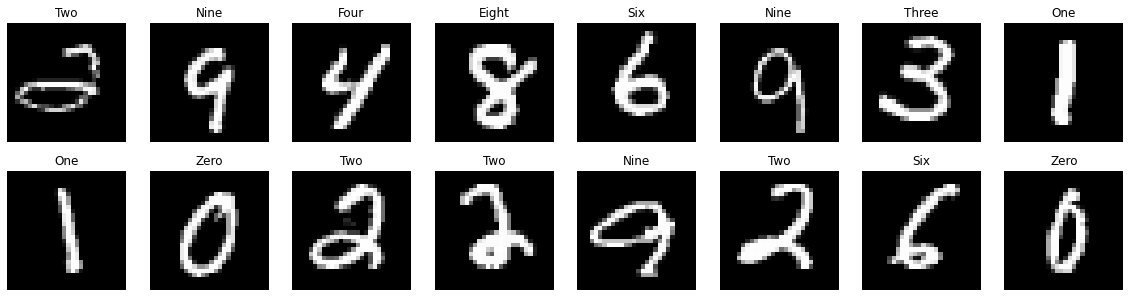

In [7]:
plt.figure(figsize=(20, 5))

for i, (image, label)  in enumerate(train_dataloader):
    if i == 8:
        break
    nrow = 2
    ncol = min(8, int(TrainingConfig.BATCH_SIZE/nrow))

    for i in range(nrow*ncol):
        ax = plt.subplot(nrow, ncol, i + 1)
        plt.title(label_dict[int(label[i])])
        plt.imshow(np.squeeze(image[i].permute(1, 2, 0), axis=2), cmap='gray')
        plt.axis("off")
    break;

## 5 The Generator Network

The generator model for a CGAN requires both a latent noise vector as well as a class label. This has the effect of making the point in latent space conditional on the input target label. The input target labels can be represented as one-hot encoded slices or by dense (embedded) vectors that are learned by the networks. As mentioned above, we have included both options in this notebook controlled by the `ONE_HOT_LABELS` flag. In both cases, the labels are combined with a transformed representation of the latent vector in the upstream portion of the network. Similar processing also takes place in the Discriminator, where the labels are combined with the input image.

Label embedding (when `ONE_HOT_LABELS = False`) is achieved by passing the class labels through an embedding layer in Keras to map it to a dense vector of a specified length (`TranigngConfig.EMBED_DIM`). The output of the label embedding is then passed through a fully connected layer with a linear activation before being resized. The embedding layer has weights that are learned by the network and therefore contain the information that allows the network to generate images of a specified class. If `ONE_HOT_LABELS = False`, then we model the labels as one-hot encoded slices. 

In both cases, you can think of these label representations as a means for activating the neurons associated with a particular label to synthesize an image based on a specified input label. We can therefore loosely think of the conditional Generator as being composed of N separate unconditional GAN models (one for each label).

In the Generator model below, the activations of the fully connected layer are resized into a single 7 × 7 feature map, which represents the label information. The new 7 × 7 feature map is added as one more channel to the existing 128, resulting in 129 feature maps that are then upsampled as before. The rest of the architecture consists of Conv2DTranspose => BatchNormalization => ReLU, which closely resembles the DCGAN architecture. As before, we pass the final layer's output through a `Tanh` activation to obtain a 28x28x1 resolution image.

In [8]:
class Generator(nn.Module):
    def __init__(self, num_classes):
        super(Generator, self).__init__()

        if TrainingConfig.ONE_HOT_LABELS:
            # Use one-hot labels.
            self.label = F.one_hot(tensor=torch.tensor(input_label), num_classes=num_classes)
            # Create dense layer for the label information.
            self.n_nodes = 7 * 7
            self.label_info = nn.Linear(50, self.n_nodes)
        else:
            # Embedding layer for input labels.
            self.label = nn.Embedding(num_classes, TrainingConfig.EMBED_DIM)
            self.n_nodes = 7 * 7
            self.label_info = nn.Linear(TrainingConfig.EMBED_DIM, self.n_nodes)
            
        self.n_nodes_out = 7 * 7 * 128
        self.latent_out = nn.Sequential(nn.Linear(TrainingConfig.LATENT_DIM, self.n_nodes_out), nn.LeakyReLU())

        torch.nn.init.xavier_uniform_(self.latent_out[0].weight)
    
    
        self.model = nn.Sequential(
            nn.ConvTranspose2d(129, 128, 4, 2, bias=False),
            nn.BatchNorm2d(128, momentum=0.1,  eps=0.8),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 128, 4, 2, bias=False),
            nn.BatchNorm2d(128, momentum=0.1,  eps=0.8),
            nn.ReLU(True), 
            
            nn.Conv2d(128, DatasetConfig.NUM_CHANNELS, 7, stride=1, bias=False),
            nn.Tanh()
        )

        torch.nn.init.xavier_uniform_(self.model[0].weight)
    
    def forward(self, inputs):

        noise_vector, labels = inputs
        label_out = self.label(labels)
        label_out = self.label_info(label_out)
        label_out = label_out.view(-1, 1, 7, 7)
        latent_out = self.latent_out(noise_vector)
        latent_out = latent_out.view(-1, 128, 7, 7)
        concat = torch.cat((latent_out, label_out), dim=1)
        image = self.model(concat)

        return image

In [9]:
generator = Generator(num_classes=10).to(TrainingConfig.DEVICE)
print(generator)

# Total parameters and trainable parameters.
total_params = sum(p.numel() for p in generator.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in generator.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

Generator(
  (label): Embedding(10, 50)
  (label_info): Linear(in_features=50, out_features=49, bias=True)
  (latent_out): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
  )
  (model): Sequential(
    (0): ConvTranspose2d(129, 128, kernel_size=(4, 4), stride=(2, 2), bias=False)
    (1): BatchNorm2d(128, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), bias=False)
    (4): BatchNorm2d(128, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (7): Tanh()
  )
)
1,169,591 total parameters.
1,169,591 training parameters.


## 6 The Discriminator Network

Next, we implement the CGAN Discriminator. Just as in the previous section, the network architecture should look familiar, except for the piece where we handle the input image and its label.

Like the Generator network, the Discriminator network also has two options for how the labels can be represented (using embedded labels or one-hot encoded labels, as described in the previous section). With either representation, the label information is concatenated with the input image to create a joint representation. The label information is effectively added to the image data as an additional channel. This has the effect of looking like a two-channel input image to the next convolutional layer.

After merging the label conditioned input and the input image, the rest of the architecture is just like any other binary image classification model. The last layer's output is passed through sigmoid to get the final probabilities. 

In [10]:
class Discriminator(nn.Module):
    
    def __init__(self, num_classes):
        
        super(Discriminator, self).__init__()
        
        if TrainingConfig.ONE_HOT_LABELS:
            # Use one-hot labels.
            self.label = F.one_hot(tensor=torch.tensor(input_label), num_classes=num_classes)
            # Create dense layer for the label information.
            self.n_nodes = 28 * 28
            self.label_info = nn.Linear(1, self.n_nodes)
        else:
            # Embedding layer for input labels.
            self.label = nn.Embedding(num_classes, TrainingConfig.EMBED_DIM)
            self.n_nodes = 28 * 28
            self.label_info = nn.Linear(TrainingConfig.EMBED_DIM, self.n_nodes)
    
        self.model_conv = nn.Sequential(
            nn.Conv2d(2, 128, 4, 2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 128, 4, 2, padding=1),
            nn.BatchNorm2d(128, momentum=0.1, eps=0.8),
            nn.LeakyReLU(0.2, inplace=True),
        )

        torch.nn.init.xavier_uniform_(self.model_conv[0].weight)
        
        self.model_linear = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(6272, 1),
            nn.Sigmoid()
        )
    
    def forward(self, inputs):

        img, labels = inputs
        label_out = self.label(labels)
        label_out = self.label_info(label_out)
        label_out = label_out.view(-1, 1, 28, 28)
        concat = torch.cat((img, label_out), dim=1)
        model_conv_out = self.model_conv(concat)
        output = self.model_linear(model_conv_out)
        
        return output

In [11]:
discriminator = Discriminator(num_classes=10).to(TrainingConfig.DEVICE)
print(discriminator)

# Total parameters and trainable parameters.
total_params = sum(p.numel() for p in discriminator.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in discriminator.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

Discriminator(
  (label): Embedding(10, 50)
  (label_info): Linear(in_features=50, out_features=784, bias=True)
  (model_conv): Sequential(
    (0): Conv2d(2, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (model_linear): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=6272, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
313,509 total parameters.
313,509 training parameters.


## 7 Define the Loss Function

In [12]:
BCE = nn.BCELoss()

In [13]:
def loss_func(y_true, y_pred):
    
    loss = BCE(y_pred, y_true)
    
    return loss

## 8 Define the Optimizers

In [14]:
optimizer_G = optim.Adam(
    generator.parameters(), 
    lr=TrainingConfig.LEARNING_RATE_G,
    betas=(0.5, 0.999)
)
optimizer_D = optim.Adam(
    discriminator.parameters(), 
    lr=TrainingConfig.LEARNING_RATE_D,
    betas=(0.5, 0.999)
)

## 9 Checkpointing and Creating Directories

In [15]:
if not os.path.exists(TrainingConfig.CHECKPOINT_DIR):
    os.makedirs(TrainingConfig.CHECKPOINT_DIR)
    
num_versions = len(os.listdir(TrainingConfig.CHECKPOINT_DIR)) + 1
ckpt_version_dir = TrainingConfig.CHECKPOINT_DIR + '/version_' + str(num_versions)
os.makedirs(ckpt_version_dir)

In [16]:
checkpoint_dir = TrainingConfig.CHECKPOINT_DIR
generator_ckpt = os.path.join(ckpt_version_dir, 'generator'+'.pth')
discriminatr_ckpt = os.path.join(ckpt_version_dir, 'discriminator'+'.pth')

## 10 Training

### 10.1 `train_step()` Function

The `train_step()` function contains all of the key logic required for training the CGAN. The structure of this function is very simialr to the GAN version, with the exception that each model is also supplied with a corresponding list of target labels. The input to this function are a batch of real images and the corresponding ground truth labels for those images (`targets`). The list of target labels is used to generate fake images so that when we train the Discriminator we pass an equal number of real image and fake images (both with the same list of target labels). When we compute the Discriminator loss, we do so using the predictions from the Discriminator (`y_pred_real` and `y_pred_fake`) and the corresponding ground truth labels (`labels`) for real (`1`) and fake (`0`) images. When we compute the Generator loss, we only use the predictions for the fake images but we use "real" (`misleading_labels`). If the predictions for the fake images is low, this will produce a large loss which is necessary to adjust the Discriminator weights in the right direction.

In [17]:
def train_step(real_images, targets):

    optimizer_G.zero_grad()
    optimizer_D.zero_grad()
    
    # Create ground truth labels for real and fake data.
    labels = torch.cat(
        (torch.ones(TrainingConfig.BATCH_SIZE, 1) * TrainingConfig.LABEL_SMOOTH_FAC, # Labels for real data
         torch.zeros(TrainingConfig.BATCH_SIZE, 1) # Labels for fake data
        ), dim=0
    ).to(TrainingConfig.DEVICE)
    
    # We want to fool the discriminator, so we create grond truth labels for 
    # real images even though we feed the discriminator with fake images.
    misleading_labels = torch.ones(TrainingConfig.BATCH_SIZE, 1).to(TrainingConfig.DEVICE)
    
    noise = torch.randn(
        TrainingConfig.BATCH_SIZE, 
        TrainingConfig.LATENT_DIM,
    ).to(TrainingConfig.DEVICE)
    
    #----------------------------------------------------------------
    # First, generate fake images needed for training both networks.
    #----------------------------------------------------------------
    # Generate fake images.
    fake_images = generator((noise, targets))
    
    # Predicted labels from discriminator for real images.
    y_pred_real = discriminator((real_images, targets))
    
    # Predicted labels from discriminator for fake images.
    y_pred_fake = discriminator((fake_images, targets))
    
    # Concatenate predictions for real and fake input data.
    y_pred_D = torch.cat((y_pred_real, y_pred_fake), dim=0)
    
    # Compute the discriminator loss.
    D_loss = loss_func(labels, y_pred_D)
        
    # Discriminator step.
    D_loss.backward()
    optimizer_D.step()
    
    # Generate fake images.
    fake_images = generator((noise, targets))
    
    # Predicted labels from discriminator for fake images.
    y_pred_fake = discriminator((fake_images, targets))
    
    # Compute the generator loss.
    G_loss = loss_func(misleading_labels, y_pred_fake)
    
    # Generator step.
    G_loss.backward()
    optimizer_G.step()
    
    return D_loss, G_loss

### 10.2 ` plot_images()` Convenience Function

In [18]:
def plot_images(images):

    for j in range(images.shape[0]):
        images = images.detach().cpu()
        image = (images[j, :, :, :] + 1 ) * 127.5
        image = np.squeeze(image, axis=2).reshape((28, 28))
        plt.subplot(1, images.shape[0]+1, j+1)
        plt.imshow(image, cmap='gray')
        plt.axis('off') 

### 10.3 `plot_fake_images()`

The function below is used to monitor the quality of the generated images during the training process. It uses the current state of both networks to generate and display fake images and also uses the Discriminator to predict the output for the generated images. However, none of the code below is related to training the model. It is only used to monitor the output of both models during training.

In [19]:
num_classes = 10

# Create fixed noise vector for generating example images during training.
fixed_noise = torch.randn(
    num_classes, 
    TrainingConfig.LATENT_DIM,
).to(TrainingConfig.DEVICE)

predictions_fake = []

def plot_fake_images(model_g, model_d):

    print("Discriminator evaluation (Fake):")
    plt.figure(figsize=(20, 10))

    #---------------------------------------------------
    # First display a few sample results to the console.
    #---------------------------------------------------
    
    # Create labels for each class.
    x = np.arange(0, num_classes).tolist()
    target_labels = torch.tensor(x, dtype=torch.int64).to(TrainingConfig.DEVICE)
    
    # Generate images for requested labels.
    images = model_g((fixed_noise, target_labels))

    # Display images and ground truth labels.
    plot_images(images)
    for _, id in enumerate(x):
        print("{:11}".format(id), end="")
    print("\n")

    # Discriminator predictions.
    y_pred = model_d((images, target_labels))
    y_pred = y_pred.detach().cpu().numpy() 

    # Predictions for image set.
    print("  ", end="")
    for _, value in enumerate(y_pred):
        print("{0:<11}".format(int(value*1000)/1000), end="")
    print(end="\n")

    #--------------------------------------------------------------------
    # Next, compute predictions for a single batch of data for plotting.
    #--------------------------------------------------------------------
    y_pred_mean = []
       
    # Create random labels for images in batch.
    x = np.random.randint(10, size=TrainingConfig.BATCH_SIZE)
    target_labels = torch.tensor(x, dtype=torch.int64).to(TrainingConfig.DEVICE)

    noise = torch.randn(
        TrainingConfig.BATCH_SIZE, 
        TrainingConfig.LATENT_DIM,
    ).to(TrainingConfig.DEVICE)

    # Generate images.
    images = model_g((noise, target_labels)) 
    
    # Make predictions.
    y_pred = model_d((images, target_labels))
    y_pred = y_pred.detach().cpu().numpy() 
    y_pred_mean.append(np.mean(y_pred))

    predictions_fake.append(np.mean(y_pred_mean))
        
    plt.show();

### 10.4 `plot_real_images()`

The function below is similar to the previous function. It displays sample images from the training dataset along with the Discriminator's output for those images. As above, none of the code below is related to training the model. It is only used to monitor the state of the Discriminator during training.

In [20]:
predictions_real = []

def plot_real_images(model_d):

    print("\n")
    print("Discriminator evaluation (Real):")
    plt.figure(figsize=(20, 10))

    #---------------------------------------------------
    # First display a few sample results to the console.
    #---------------------------------------------------
    for (image_batch, targets) in train_dataloader:
        
        image_batch = image_batch.to(TrainingConfig.DEVICE)
        targets = targets.to(TrainingConfig.DEVICE)

        plot_images(image_batch[0:num_classes])
        break;

    for idx in range(10):
        print("{:11}".format(targets[idx]), end="")
    print("\n")

    # Discriminator predictions.
    y_pred = model_d((image_batch[0:num_classes], targets[0:num_classes]))
    y_pred = y_pred.detach().cpu().numpy() 

    # Predictions for image set.
    print("  ", end="")
    for _, value in enumerate(y_pred):
        print("  {0:<10}".format(int(value*1000)/1000), end="")
    print(end="\n")

    #--------------------------------------------------------------------
    # Next, compute predictions for a single batch of data for plotting.
    #--------------------------------------------------------------------
    y_pred_mean = []
    for (image_batch, targets) in train_dataloader:
        
        image_batch = image_batch.to(TrainingConfig.DEVICE)
        targets = targets.to(TrainingConfig.DEVICE)

        y_pred = model_d((image_batch, targets))
        y_pred = y_pred.detach().cpu().numpy() 
        y_pred_mean.append(np.mean(y_pred))
        break;

    predictions_real.append(np.mean(y_pred_mean))
        
    plt.show();

### 10.3 `train()` Function

In [21]:
G_LOSS = []
D_LOSS = []

def train(dataloader, epochs):
    
    for epoch in range(epochs):
        
        generator.train()
        discriminator.train()
        start = time.time()
        i = 0
        D_loss_list, G_loss_list = [], []
        
        for _, data in tqdm(enumerate(dataloader), total=int(len(dataloader))):
            image_batch, targets = data
            image_batch = image_batch.to(TrainingConfig.DEVICE)
            targets = targets.to(TrainingConfig.DEVICE)
            
            i += 1
            
            D_loss, G_loss = train_step(image_batch, targets)
            
            D_loss_list.append(D_loss)
            G_loss_list.append(G_loss)
            
        if (epoch + 1) % 5 == 0:
            torch.save(generator, generator_ckpt)
            torch.save(discriminator, discriminatr_ckpt)
            
        epoch_D_loss = sum(D_loss_list)/len(D_loss_list)
        epoch_G_loss = sum(G_loss_list)/len(G_loss_list)

        D_LOSS.append(epoch_D_loss.detach().cpu())
        G_LOSS.append(epoch_G_loss.detach().cpu())
        
        print('\n')
        print(f"Time for epoch {epoch + 1} is {time.time()-start} sec")
        print(f"Generator loss: {epoch_G_loss:.3f}, Discriminator loss: {epoch_D_loss:.3f}")

        plot_fake_images(generator, discriminator)
        plot_real_images(discriminator)

### 10.4 Train the GAN

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 1 is 33.37740707397461 sec
Generator loss: 1.261, Discriminator loss: 0.563
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.303      0.525      0.172      0.386      0.285      0.123      0.257      0.398      0.744      0.296      


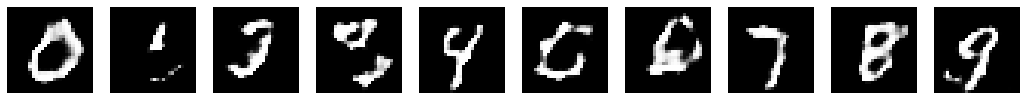



Discriminator evaluation (Real):
          0          0          6          7          7          7          3          0          3          3

    0.748       0.292       0.343       0.444       0.654       0.354       0.597       0.296       0.483       0.617     


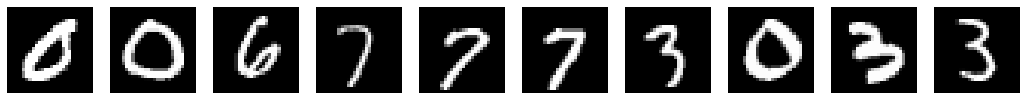

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 2 is 27.476873636245728 sec
Generator loss: 1.126, Discriminator loss: 0.592
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.598      0.343      0.477      0.464      0.313      0.454      0.338      0.403      0.561      0.405      


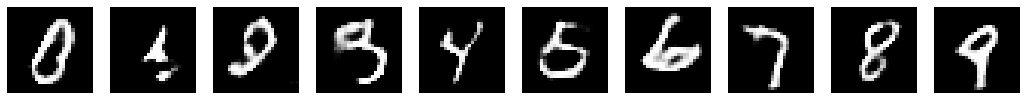



Discriminator evaluation (Real):
          7          5          5          7          3          0          4          1          7          9

    0.435       0.325       0.933       0.798       0.487       0.568       0.505       0.553       0.594       0.562     


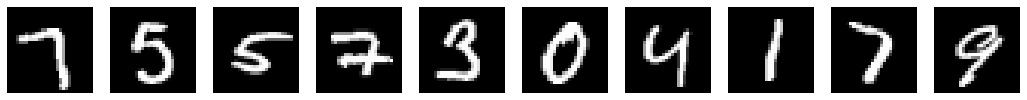

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 3 is 28.526862382888794 sec
Generator loss: 1.093, Discriminator loss: 0.610
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.543      0.173      0.346      0.298      0.2        0.352      0.404      0.407      0.212      0.25       


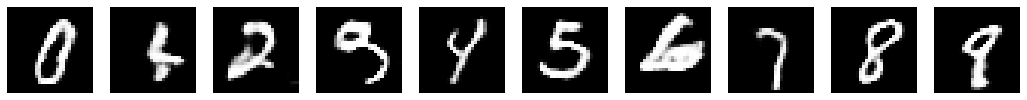



Discriminator evaluation (Real):
          1          1          0          7          3          4          4          2          8          4

    0.378       0.254       0.308       0.624       0.493       0.201       0.354       0.458       0.682       0.484     


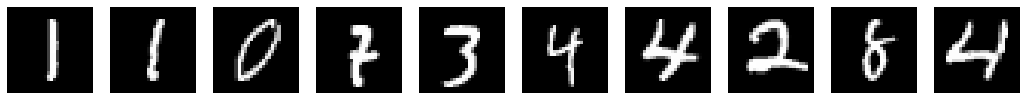

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 4 is 27.385445594787598 sec
Generator loss: 1.067, Discriminator loss: 0.618
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.112      0.251      0.228      0.229      0.331      0.462      0.511      0.338      0.443      0.159      


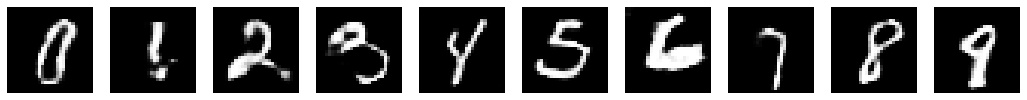



Discriminator evaluation (Real):
          5          3          7          7          2          1          7          4          0          7

    0.396       0.505       0.706       0.34        0.369       0.481       0.316       0.293       0.704       0.498     


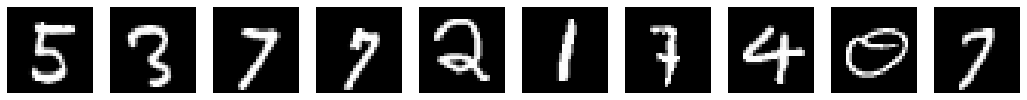

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 5 is 27.939098834991455 sec
Generator loss: 1.066, Discriminator loss: 0.620
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.069      0.482      0.641      0.138      0.434      0.418      0.711      0.279      0.221      0.177      


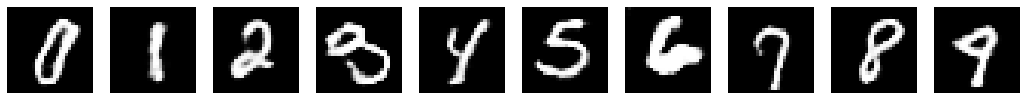



Discriminator evaluation (Real):
          1          5          1          5          5          5          6          7          4          0

    0.337       0.668       0.503       0.299       0.542       0.252       0.694       0.227       0.426       0.5       


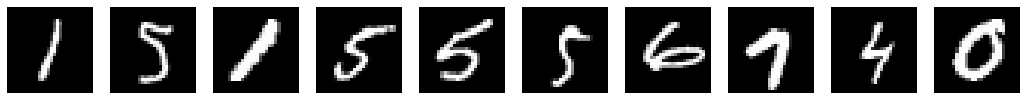

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 6 is 28.390850067138672 sec
Generator loss: 1.074, Discriminator loss: 0.619
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.517      0.403      0.276      0.139      0.361      0.466      0.429      0.568      0.21       0.549      


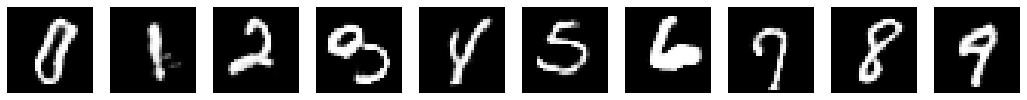



Discriminator evaluation (Real):
          0          8          6          3          7          2          0          1          5          0

    0.634       0.121       0.623       0.557       0.294       0.322       0.518       0.356       0.51        0.473     


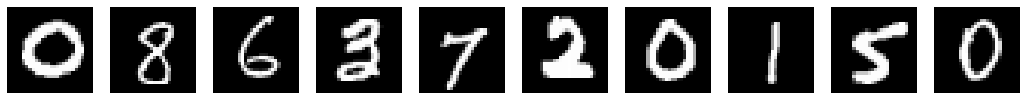

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 7 is 27.90006995201111 sec
Generator loss: 1.097, Discriminator loss: 0.614
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.21       0.304      0.121      0.119      0.311      0.225      0.237      0.301      0.205      0.417      


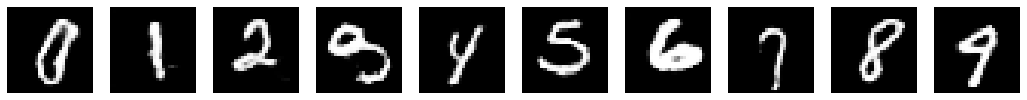



Discriminator evaluation (Real):
          0          6          7          3          7          6          0          6          2          0

    0.46        0.297       0.298       0.392       0.303       0.432       0.581       0.296       0.27        0.509     


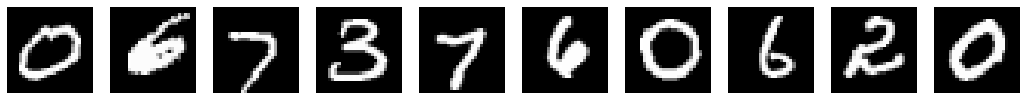

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 8 is 27.986306190490723 sec
Generator loss: 1.118, Discriminator loss: 0.609
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.128      0.348      0.238      0.502      0.425      0.33       0.315      0.302      0.29       0.284      


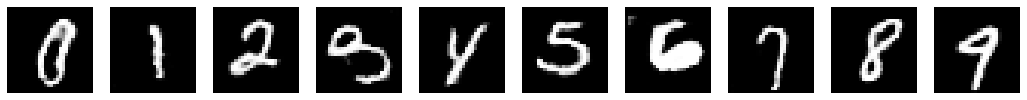



Discriminator evaluation (Real):
          7          2          3          4          1          5          1          9          9          7

    0.524       0.228       0.754       0.624       0.562       0.334       0.56        0.469       0.597       0.586     


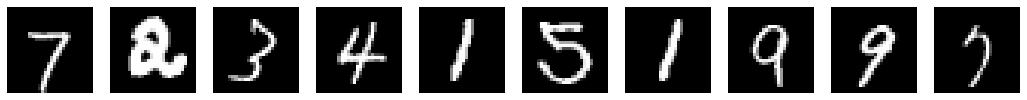

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 9 is 27.686206102371216 sec
Generator loss: 1.137, Discriminator loss: 0.605
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.511      0.436      0.452      0.133      0.139      0.571      0.452      0.405      0.454      0.406      


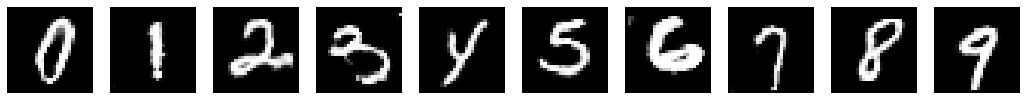



Discriminator evaluation (Real):
          7          4          1          1          9          3          1          6          1          5

    0.539       0.754       0.141       0.434       0.255       0.2         0.309       0.305       0.377       0.423     


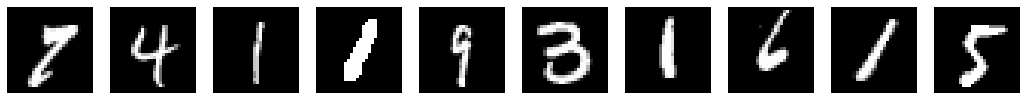

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 10 is 27.872175216674805 sec
Generator loss: 1.141, Discriminator loss: 0.605
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.277      0.222      0.304      0.163      0.176      0.204      0.191      0.401      0.15       0.211      


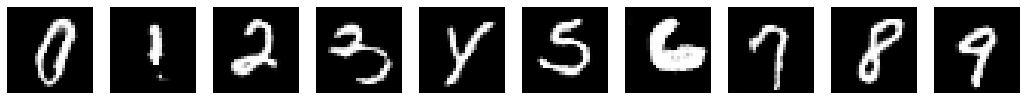



Discriminator evaluation (Real):
          3          8          7          5          3          4          7          0          8          5

    0.453       0.371       0.683       0.26        0.246       0.446       0.359       0.745       0.642       0.292     


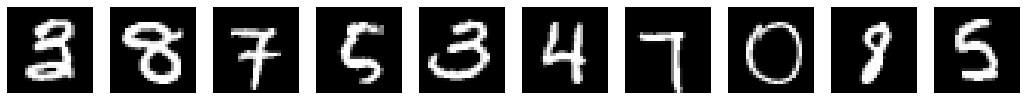

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 11 is 27.233229637145996 sec
Generator loss: 1.145, Discriminator loss: 0.607
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.196      0.164      0.174      0.169      0.143      0.223      0.168      0.252      0.127      0.162      


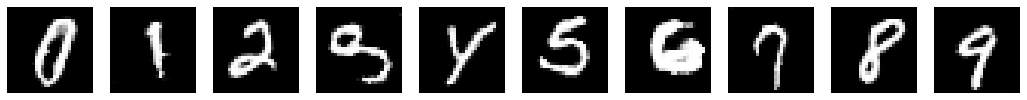



Discriminator evaluation (Real):
          1          0          2          8          9          8          3          5          5          3

    0.438       0.324       0.499       0.124       0.318       0.246       0.505       0.35        0.185       0.337     


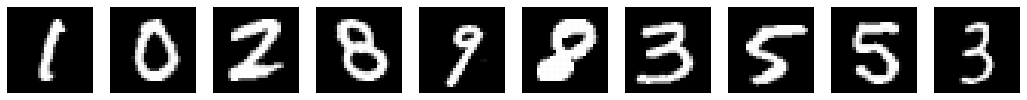

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 12 is 28.071780681610107 sec
Generator loss: 1.132, Discriminator loss: 0.609
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.364      0.283      0.425      0.166      0.246      0.183      0.219      0.608      0.15       0.431      


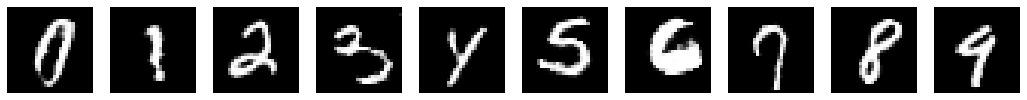



Discriminator evaluation (Real):
          7          9          9          0          7          4          4          3          9          7

    0.435       0.365       0.651       0.382       0.412       0.256       0.37        0.202       0.38        0.55      


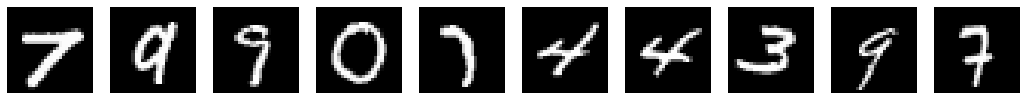

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 13 is 28.626930475234985 sec
Generator loss: 1.125, Discriminator loss: 0.612
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.259      0.18       0.355      0.252      0.299      0.584      0.127      0.359      0.175      0.308      


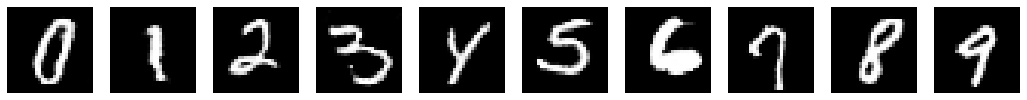



Discriminator evaluation (Real):
          9          8          0          1          3          9          9          3          1          7

    0.363       0.457       0.583       0.286       0.376       0.414       0.326       0.402       0.268       0.331     


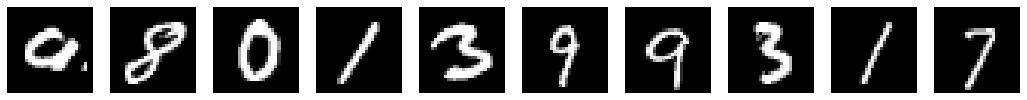

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 14 is 27.90306854248047 sec
Generator loss: 1.113, Discriminator loss: 0.618
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.139      0.093      0.337      0.269      0.283      0.413      0.128      0.252      0.259      0.392      


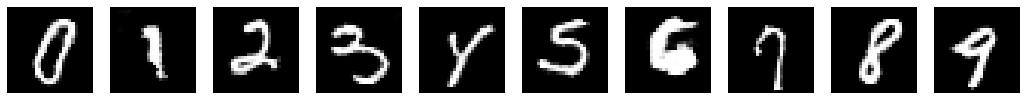



Discriminator evaluation (Real):
          0          4          5          1          3          6          4          7          0          6

    0.612       0.678       0.596       0.474       0.61        0.491       0.316       0.44        0.381       0.377     


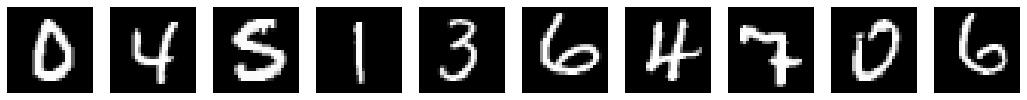

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 15 is 27.729406595230103 sec
Generator loss: 1.106, Discriminator loss: 0.619
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.238      0.279      0.364      0.504      0.476      0.353      0.664      0.471      0.283      0.476      


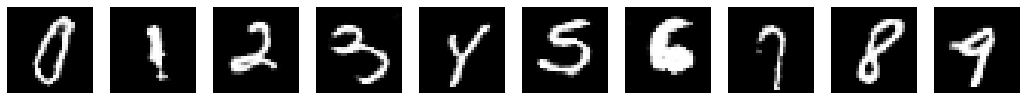



Discriminator evaluation (Real):
          3          4          1          3          8          0          4          8          5          5

    0.527       0.556       0.771       0.658       0.775       0.662       0.734       0.603       0.552       0.709     


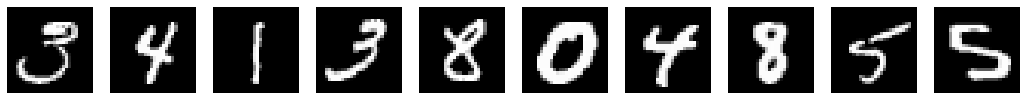

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 16 is 27.862034797668457 sec
Generator loss: 1.098, Discriminator loss: 0.622
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.142      0.34       0.149      0.319      0.419      0.286      0.587      0.363      0.215      0.429      


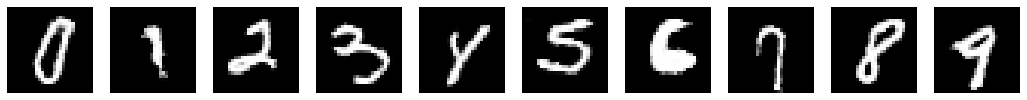



Discriminator evaluation (Real):
          1          9          1          6          1          1          2          4          2          0

    0.531       0.374       0.324       0.396       0.504       0.54        0.633       0.195       0.648       0.563     


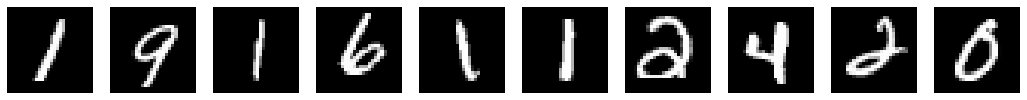

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 17 is 28.112460613250732 sec
Generator loss: 1.090, Discriminator loss: 0.626
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.231      0.176      0.207      0.175      0.323      0.221      0.388      0.304      0.437      0.254      


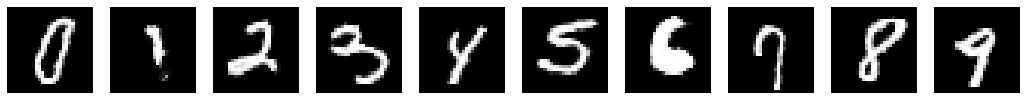



Discriminator evaluation (Real):
          0          7          8          1          0          7          9          6          2          3

    0.617       0.411       0.386       0.394       0.244       0.381       0.534       0.36        0.425       0.549     


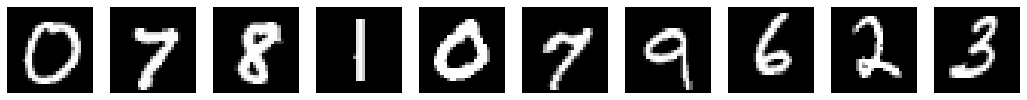

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 18 is 29.868830680847168 sec
Generator loss: 1.084, Discriminator loss: 0.627
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.526      0.258      0.378      0.404      0.359      0.575      0.454      0.321      0.356      0.54       


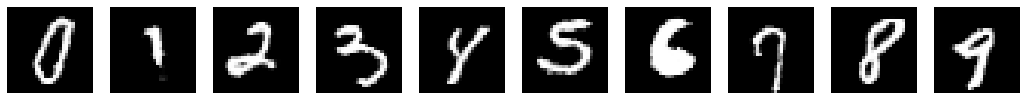



Discriminator evaluation (Real):
          2          4          9          7          4          1          6          9          8          0

    0.549       0.708       0.588       0.504       0.359       0.425       0.64        0.468       0.74        0.642     


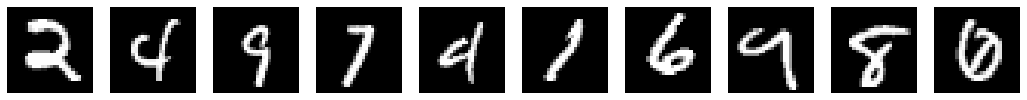

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 19 is 27.901824235916138 sec
Generator loss: 1.076, Discriminator loss: 0.629
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.172      0.286      0.247      0.356      0.392      0.219      0.621      0.293      0.18       0.251      


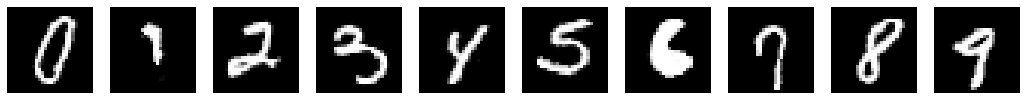



Discriminator evaluation (Real):
          6          4          7          6          7          1          1          8          8          3

    0.597       0.41        0.404       0.536       0.584       0.597       0.312       0.376       0.437       0.467     


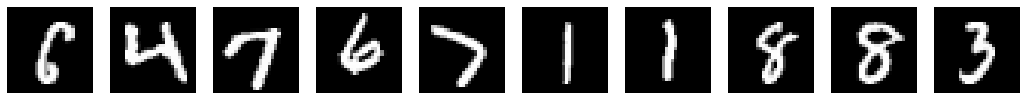

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 20 is 27.39704990386963 sec
Generator loss: 1.076, Discriminator loss: 0.630
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.438      0.127      0.203      0.241      0.17       0.278      0.472      0.195      0.258      0.366      


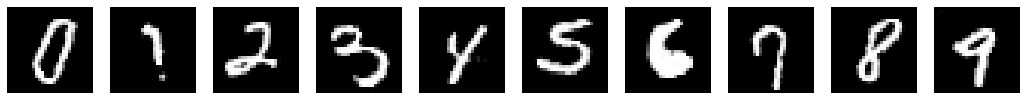



Discriminator evaluation (Real):
          1          8          7          2          6          4          7          1          1          1

    0.32        0.456       0.301       0.653       0.346       0.503       0.352       0.507       0.261       0.512     


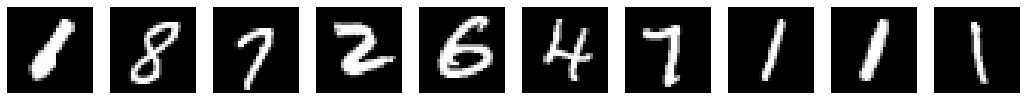

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 21 is 27.634066104888916 sec
Generator loss: 1.069, Discriminator loss: 0.632
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.288      0.324      0.2        0.56       0.573      0.343      0.393      0.274      0.504      0.479      


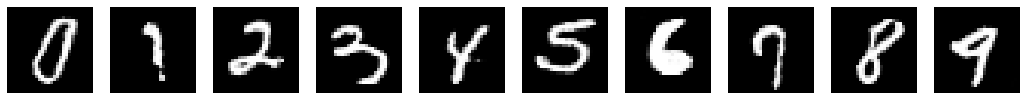



Discriminator evaluation (Real):
          3          4          7          2          0          7          7          8          6          1

    0.767       0.604       0.537       0.601       0.462       0.571       0.219       0.676       0.645       0.473     


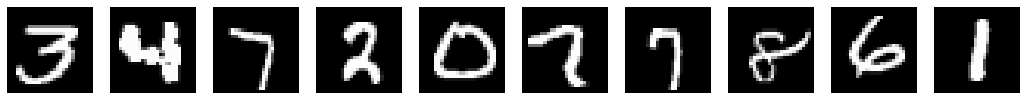

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 22 is 28.34317636489868 sec
Generator loss: 1.069, Discriminator loss: 0.632
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.273      0.59       0.335      0.438      0.233      0.324      0.475      0.29       0.375      0.173      


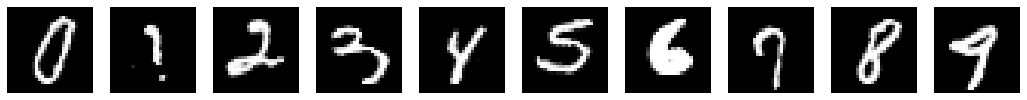



Discriminator evaluation (Real):
          5          1          7          9          9          9          2          2          5          2

    0.635       0.39        0.362       0.461       0.55        0.632       0.391       0.613       0.56        0.461     


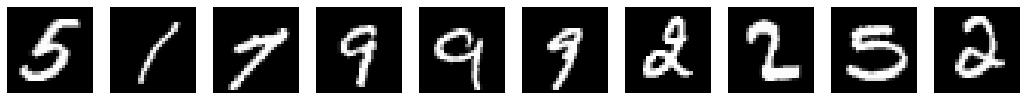

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 23 is 27.869890451431274 sec
Generator loss: 1.065, Discriminator loss: 0.634
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.549      0.38       0.565      0.319      0.713      0.415      0.679      0.357      0.429      0.379      


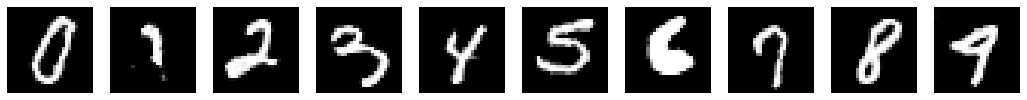



Discriminator evaluation (Real):
          0          4          5          3          4          1          8          2          1          1

    0.509       0.453       0.507       0.526       0.514       0.388       0.375       0.433       0.607       0.586     


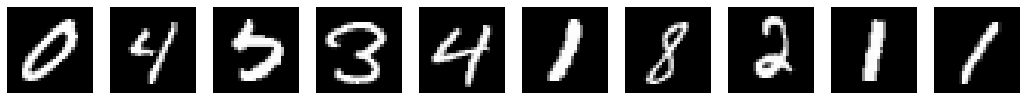

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 24 is 27.735357761383057 sec
Generator loss: 1.063, Discriminator loss: 0.634
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.18       0.272      0.215      0.479      0.444      0.253      0.394      0.473      0.104      0.521      


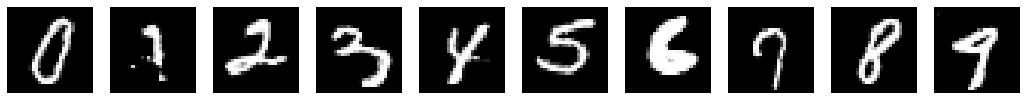



Discriminator evaluation (Real):
          9          4          9          9          0          7          0          5          9          9

    0.368       0.574       0.563       0.7         0.431       0.509       0.548       0.723       0.414       0.389     


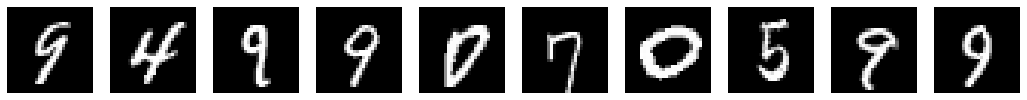

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 25 is 27.74319815635681 sec
Generator loss: 1.051, Discriminator loss: 0.636
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.218      0.278      0.346      0.436      0.444      0.296      0.619      0.232      0.281      0.504      


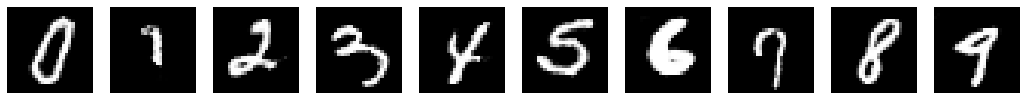



Discriminator evaluation (Real):
          2          0          1          1          8          8          7          7          3          1

    0.517       0.597       0.557       0.586       0.43        0.38        0.697       0.803       0.553       0.532     


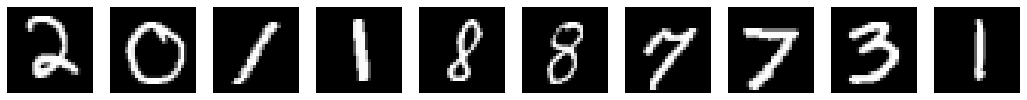

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 26 is 27.747265815734863 sec
Generator loss: 1.055, Discriminator loss: 0.637
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.342      0.146      0.747      0.383      0.285      0.293      0.7        0.398      0.169      0.195      


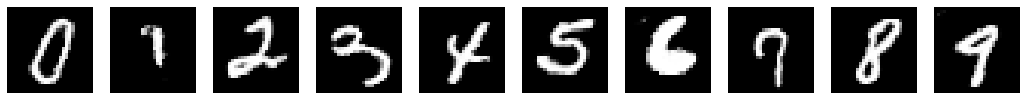



Discriminator evaluation (Real):
          2          9          1          2          0          1          8          0          7          9

    0.466       0.661       0.633       0.515       0.363       0.319       0.513       0.461       0.549       0.293     


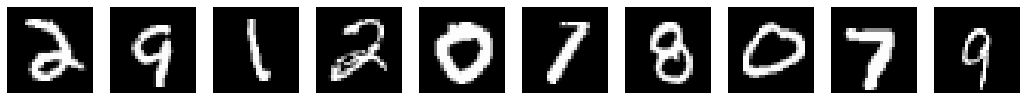

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 27 is 27.786928176879883 sec
Generator loss: 1.047, Discriminator loss: 0.639
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.21       0.239      0.283      0.283      0.466      0.614      0.516      0.384      0.236      0.563      


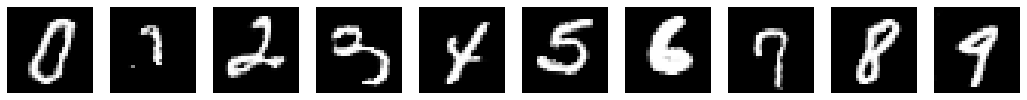



Discriminator evaluation (Real):
          3          6          5          7          3          2          5          9          5          7

    0.142       0.545       0.323       0.428       0.275       0.356       0.625       0.461       0.216       0.395     


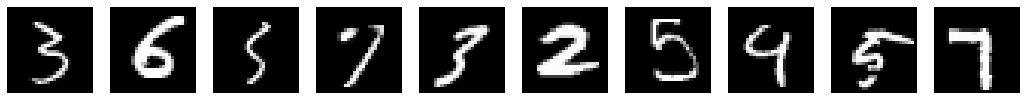

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 28 is 27.225366592407227 sec
Generator loss: 1.048, Discriminator loss: 0.638
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.374      0.666      0.628      0.326      0.541      0.591      0.582      0.505      0.468      0.716      


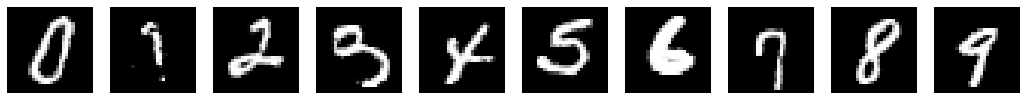



Discriminator evaluation (Real):
          9          8          6          7          2          8          0          9          4          8

    0.673       0.739       0.808       0.758       0.714       0.608       0.633       0.453       0.834       0.792     


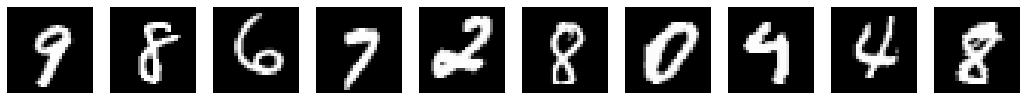

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 29 is 27.41060996055603 sec
Generator loss: 1.042, Discriminator loss: 0.640
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.446      0.277      0.46       0.305      0.391      0.268      0.808      0.4        0.339      0.623      


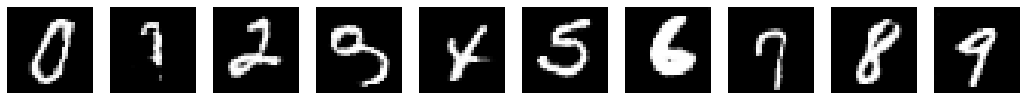



Discriminator evaluation (Real):
          4          6          9          9          2          9          1          6          5          3

    0.565       0.736       0.685       0.463       0.338       0.766       0.623       0.701       0.695       0.712     


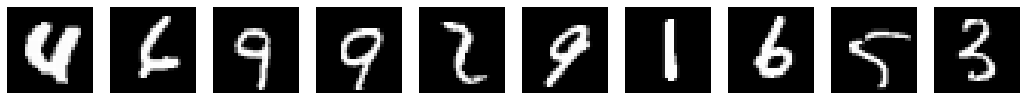

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 30 is 27.60526132583618 sec
Generator loss: 1.040, Discriminator loss: 0.641
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.612      0.354      0.171      0.266      0.666      0.429      0.679      0.521      0.553      0.342      


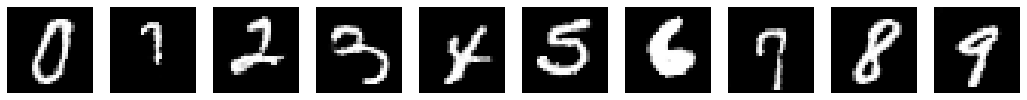



Discriminator evaluation (Real):
          2          3          7          6          0          3          0          5          3          3

    0.688       0.512       0.481       0.686       0.765       0.301       0.786       0.59        0.288       0.515     


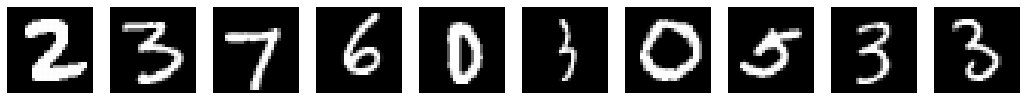

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 31 is 28.517167806625366 sec
Generator loss: 1.040, Discriminator loss: 0.640
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.391      0.612      0.244      0.346      0.306      0.602      0.471      0.642      0.204      0.277      


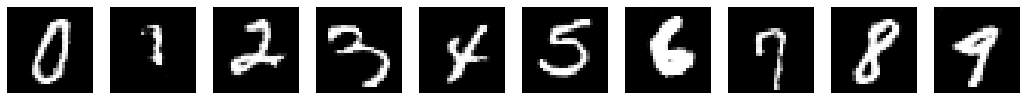



Discriminator evaluation (Real):
          9          2          7          8          9          0          1          2          6          4

    0.335       0.466       0.363       0.474       0.413       0.555       0.44        0.516       0.789       0.581     


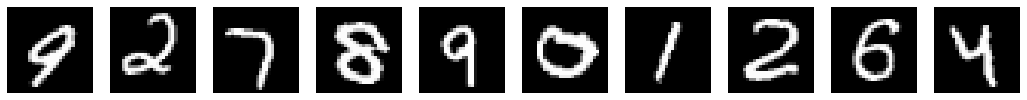

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 32 is 27.989696979522705 sec
Generator loss: 1.035, Discriminator loss: 0.642
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.515      0.563      0.643      0.37       0.719      0.406      0.609      0.407      0.477      0.532      


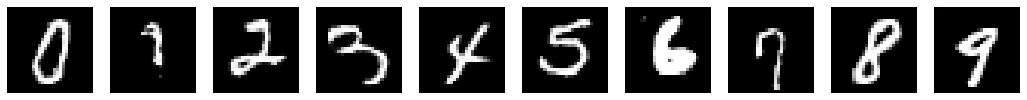



Discriminator evaluation (Real):
          2          1          1          1          7          4          9          7          8          0

    0.426       0.397       0.538       0.533       0.37        0.47        0.521       0.534       0.697       0.51      


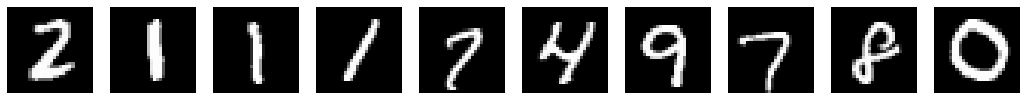

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 33 is 27.209054946899414 sec
Generator loss: 1.033, Discriminator loss: 0.642
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.577      0.317      0.552      0.351      0.573      0.692      0.743      0.223      0.369      0.577      


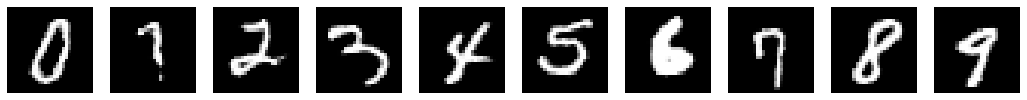



Discriminator evaluation (Real):
          0          8          4          1          2          3          4          3          1          4

    0.845       0.324       0.56        0.303       0.735       0.26        0.512       0.647       0.309       0.697     


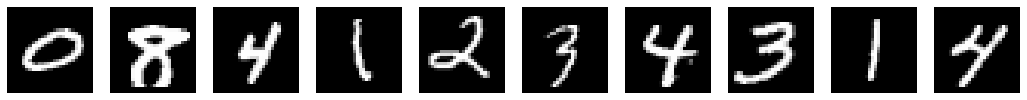

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 34 is 27.81302523612976 sec
Generator loss: 1.032, Discriminator loss: 0.643
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.374      0.547      0.555      0.336      0.556      0.521      0.557      0.456      0.611      0.752      


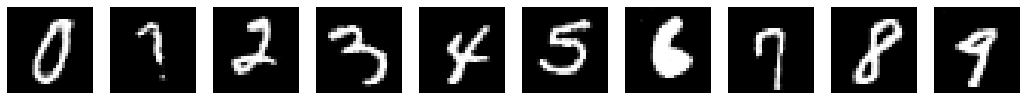



Discriminator evaluation (Real):
          8          0          9          6          5          9          8          9          1          9

    0.484       0.801       0.306       0.751       0.747       0.343       0.377       0.812       0.603       0.456     


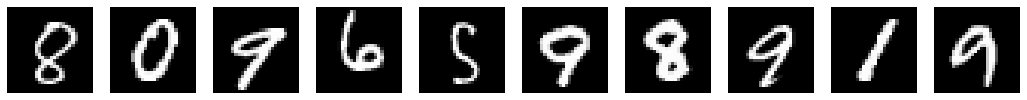

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 35 is 28.478628873825073 sec
Generator loss: 1.029, Discriminator loss: 0.642
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.597      0.423      0.516      0.288      0.371      0.466      0.661      0.566      0.638      0.332      


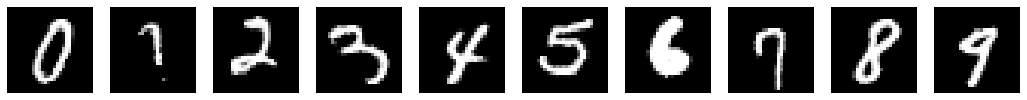



Discriminator evaluation (Real):
          9          9          9          6          6          7          0          8          9          6

    0.797       0.759       0.554       0.491       0.23        0.894       0.53        0.487       0.8         0.621     


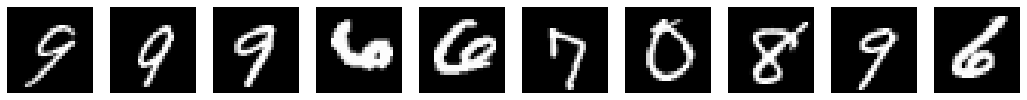

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 36 is 27.398563623428345 sec
Generator loss: 1.033, Discriminator loss: 0.642
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.391      0.505      0.443      0.53       0.335      0.707      0.447      0.625      0.408      0.353      


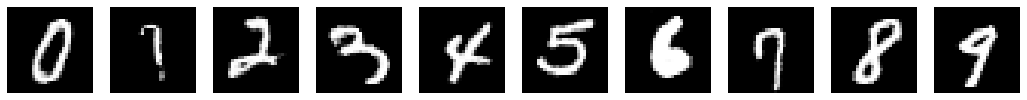



Discriminator evaluation (Real):
          4          3          0          7          1          2          3          7          0          0

    0.39        0.309       0.699       0.465       0.65        0.498       0.604       0.685       0.504       0.549     


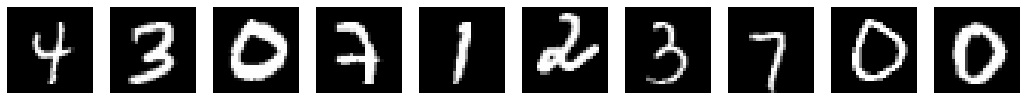

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 37 is 27.341456651687622 sec
Generator loss: 1.030, Discriminator loss: 0.643
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.39       0.366      0.347      0.41       0.414      0.478      0.612      0.402      0.416      0.405      


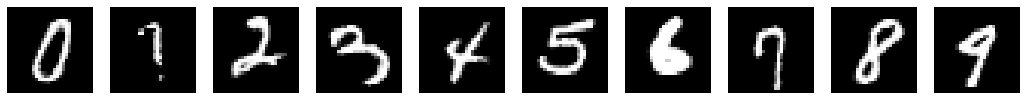



Discriminator evaluation (Real):
          4          7          8          5          4          9          6          9          0          6

    0.728       0.595       0.731       0.502       0.52        0.805       0.337       0.347       0.719       0.696     


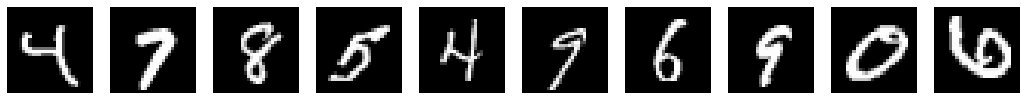

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 38 is 27.66073989868164 sec
Generator loss: 1.026, Discriminator loss: 0.645
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.288      0.243      0.396      0.291      0.58       0.364      0.432      0.354      0.218      0.642      


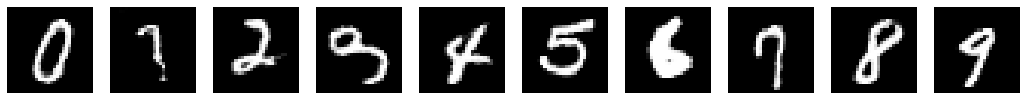



Discriminator evaluation (Real):
          5          1          6          7          6          7          7          3          8          6

    0.545       0.46        0.248       0.629       0.31        0.554       0.492       0.533       0.361       0.401     


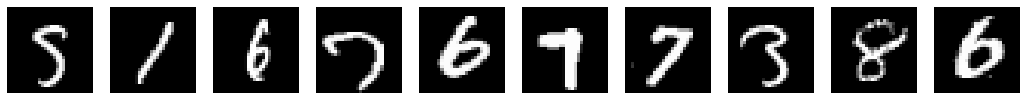

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 39 is 28.03093147277832 sec
Generator loss: 1.030, Discriminator loss: 0.644
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.52       0.354      0.634      0.416      0.691      0.37       0.445      0.304      0.261      0.403      


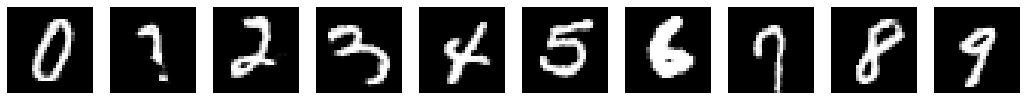



Discriminator evaluation (Real):
          1          6          8          9          3          0          1          2          3          2

    0.619       0.543       0.668       0.655       0.446       0.395       0.55        0.768       0.631       0.695     


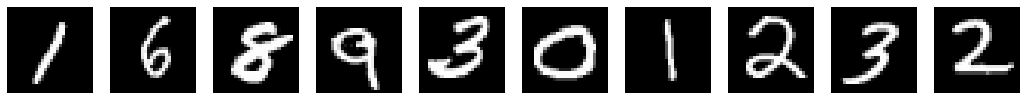

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 40 is 27.725231885910034 sec
Generator loss: 1.024, Discriminator loss: 0.643
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.415      0.626      0.541      0.48       0.601      0.534      0.434      0.542      0.267      0.612      


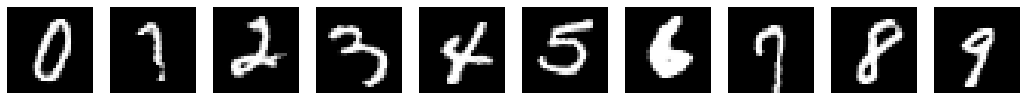



Discriminator evaluation (Real):
          5          3          6          9          9          4          1          6          2          4

    0.828       0.68        0.456       0.724       0.52        0.594       0.447       0.57        0.667       0.546     


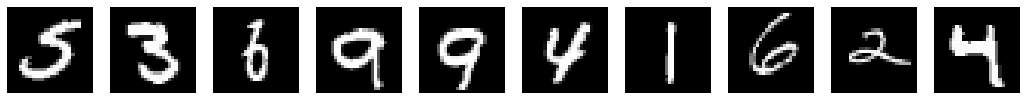

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 41 is 27.609883785247803 sec
Generator loss: 1.031, Discriminator loss: 0.643
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.227      0.405      0.368      0.435      0.607      0.519      0.307      0.543      0.251      0.592      


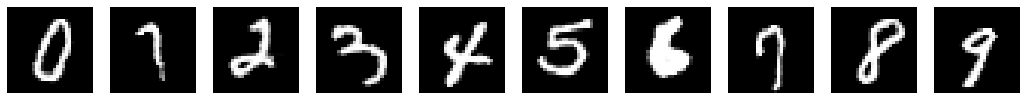



Discriminator evaluation (Real):
          2          5          1          7          9          0          8          3          8          5

    0.41        0.463       0.362       0.48        0.534       0.247       0.649       0.549       0.622       0.236     


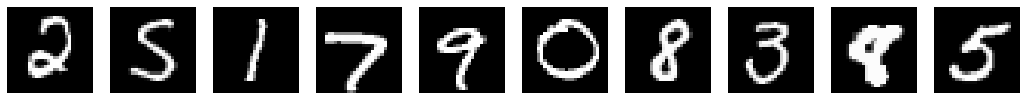

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 42 is 27.705571174621582 sec
Generator loss: 1.028, Discriminator loss: 0.642
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.3        0.408      0.242      0.354      0.28       0.579      0.767      0.52       0.351      0.25       


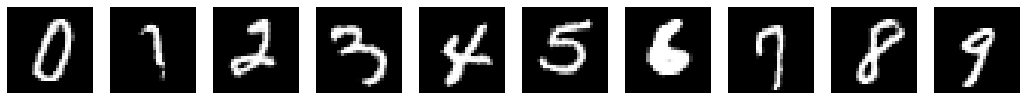



Discriminator evaluation (Real):
          0          3          3          2          9          9          7          7          4          7

    0.661       0.723       0.414       0.628       0.501       0.325       0.476       0.376       0.48        0.385     


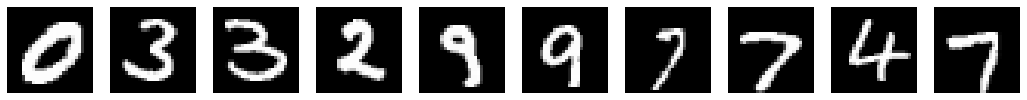

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 43 is 28.01480770111084 sec
Generator loss: 1.033, Discriminator loss: 0.643
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.422      0.231      0.362      0.556      0.382      0.514      0.22       0.569      0.342      0.277      


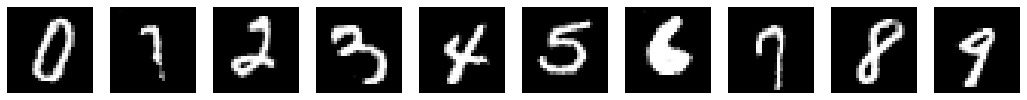



Discriminator evaluation (Real):
          3          2          0          8          3          8          8          1          9          7

    0.548       0.638       0.707       0.391       0.265       0.692       0.326       0.443       0.138       0.376     


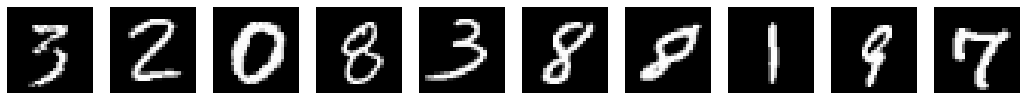

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 44 is 27.890607118606567 sec
Generator loss: 1.032, Discriminator loss: 0.642
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.454      0.3        0.47       0.363      0.305      0.324      0.251      0.524      0.413      0.546      


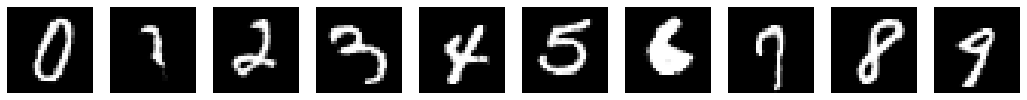



Discriminator evaluation (Real):
          0          8          2          7          8          7          4          2          5          7

    0.373       0.637       0.383       0.235       0.863       0.249       0.477       0.572       0.321       0.342     


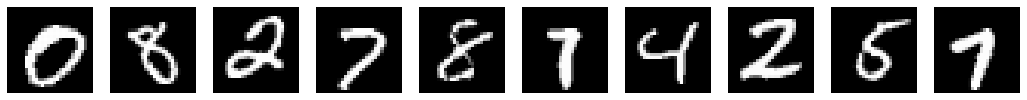

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 45 is 27.463546752929688 sec
Generator loss: 1.034, Discriminator loss: 0.641
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.44       0.532      0.278      0.34       0.242      0.257      0.427      0.231      0.546      0.567      


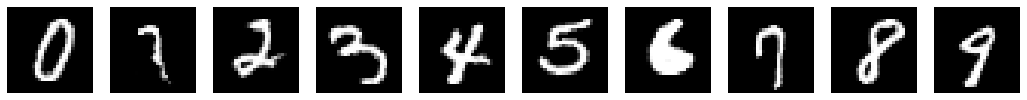



Discriminator evaluation (Real):
          7          2          9          9          9          5          7          0          7          6

    0.609       0.397       0.62        0.447       0.458       0.454       0.544       0.53        0.233       0.314     


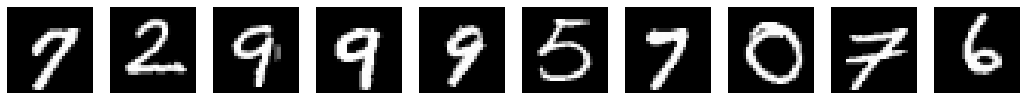

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 46 is 28.396231174468994 sec
Generator loss: 1.040, Discriminator loss: 0.641
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.547      0.342      0.441      0.49       0.37       0.556      0.274      0.553      0.47       0.586      


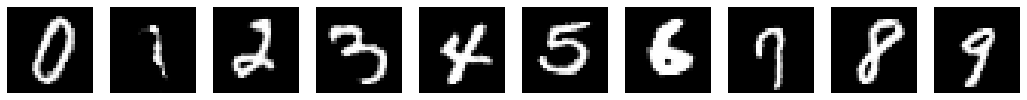



Discriminator evaluation (Real):
          1          0          6          9          7          0          9          3          0          5

    0.515       0.39        0.608       0.812       0.765       0.412       0.487       0.583       0.256       0.735     


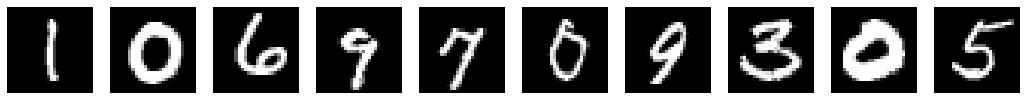

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 47 is 28.058701753616333 sec
Generator loss: 1.041, Discriminator loss: 0.641
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.306      0.64       0.181      0.417      0.133      0.264      0.407      0.304      0.198      0.351      


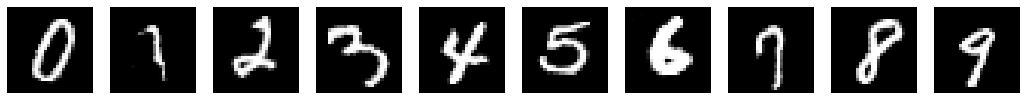



Discriminator evaluation (Real):
          0          0          3          4          1          0          2          5          0          1

    0.746       0.539       0.528       0.854       0.639       0.348       0.634       0.618       0.613       0.478     


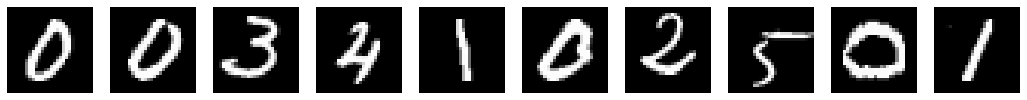

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 48 is 27.66118574142456 sec
Generator loss: 1.044, Discriminator loss: 0.640
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.463      0.204      0.614      0.579      0.284      0.494      0.394      0.423      0.381      0.549      


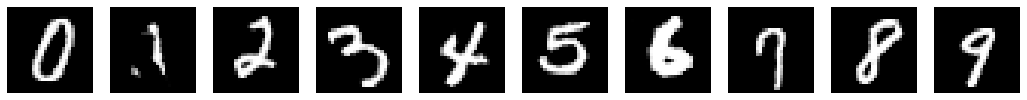



Discriminator evaluation (Real):
          5          6          5          6          8          7          3          8          4          7

    0.706       0.51        0.348       0.31        0.477       0.429       0.677       0.418       0.464       0.255     


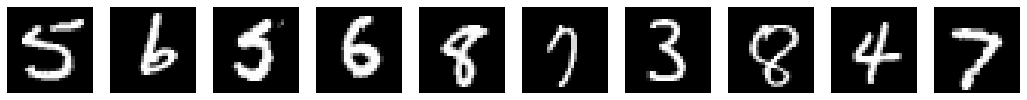

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 49 is 27.583415031433105 sec
Generator loss: 1.046, Discriminator loss: 0.637
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.253      0.533      0.436      0.649      0.282      0.473      0.517      0.312      0.274      0.662      


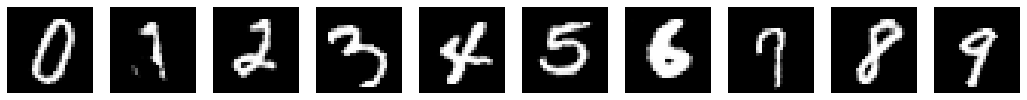



Discriminator evaluation (Real):
          7          2          1          5          7          9          2          5          1          2

    0.475       0.531       0.222       0.428       0.389       0.17        0.61        0.371       0.275       0.535     


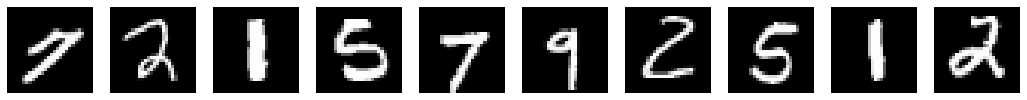

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 50 is 28.84476900100708 sec
Generator loss: 1.052, Discriminator loss: 0.637
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.291      0.469      0.609      0.537      0.45       0.675      0.537      0.296      0.528      0.711      


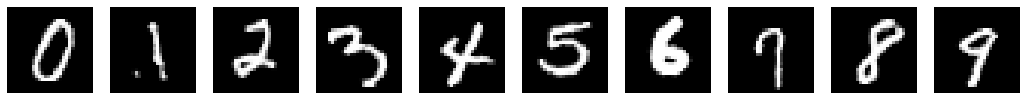



Discriminator evaluation (Real):
          7          2          8          4          5          0          3          6          0          9

    0.657       0.615       0.8         0.764       0.431       0.479       0.663       0.765       0.624       0.577     


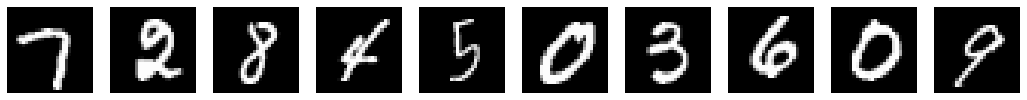

  0%|          | 0/1875 [00:00<?, ?it/s]



Time for epoch 51 is 28.345942735671997 sec
Generator loss: 1.055, Discriminator loss: 0.635
Discriminator evaluation (Fake):
          0          1          2          3          4          5          6          7          8          9

  0.243      0.238      0.544      0.379      0.48       0.298      0.391      0.586      0.413      0.734      


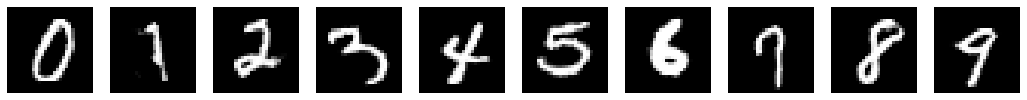



Discriminator evaluation (Real):
          1          0          3          7          6          5          8          8          6          9

    0.431       0.596       0.347       0.512       0.791       0.66        0.404       0.284       0.576       0.707     


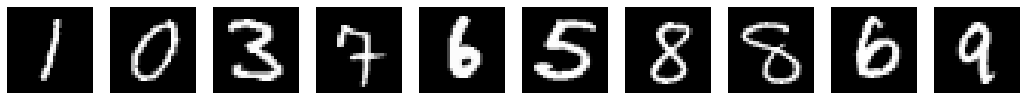

In [22]:
train(train_dataloader, TrainingConfig.NUM_EPOCHS)

## 11 Plot the Training Results

In [23]:
def plot_results(metrics, ylabel=None, ylim=None, metric_name=None, color=None):
    
    fig, ax = plt.subplots(figsize=(18, 5))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]
    
    for idx, metric in enumerate(metrics):    
        ax.plot(metric, color=color[idx])
    
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(ylabel)
    plt.xlim([0, TrainingConfig.NUM_EPOCHS-1])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)   

    plt.show(block=block_plot)
    plt.close()

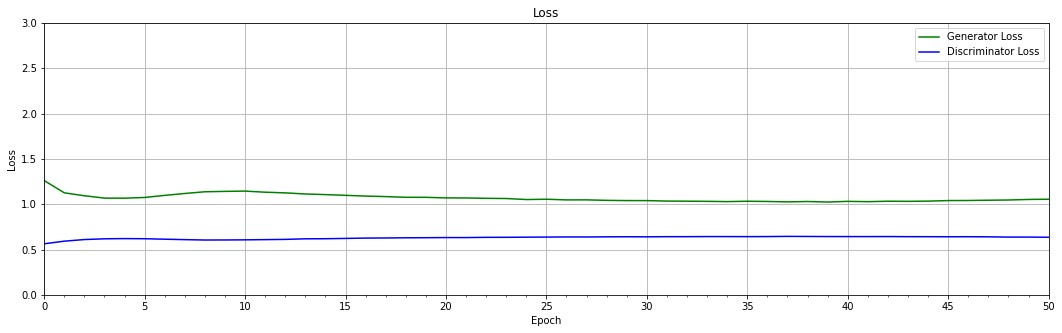

In [24]:
plot_results([G_LOSS, D_LOSS],        
             ylabel='Loss', 
             ylim=[0,3],
             metric_name=['Generator Loss', 'Discriminator Loss'],
             color=['g', 'b']);

As we have noted previously, it can be hard to judge the quality of the generated image based solely on the loss curves. In general, the loss curves tend to be more informative when things are going poorly (for example, a Discriminator loss quickly converging to zero). That said, the loss curves above are very well behaved and clearly show a state of equilibrium between the two models.

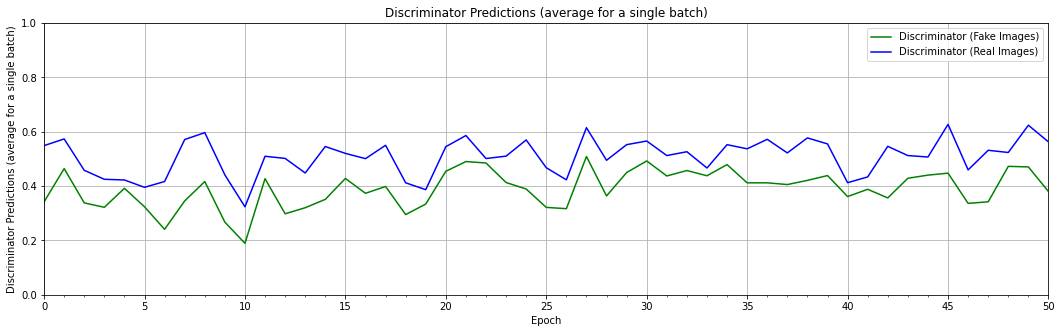

In [25]:
plot_results([predictions_fake, predictions_real],       
            ylabel="Discriminator Predictions (average for a single batch)", 
            ylim=[0, 1],
            metric_name=["Discriminator (Fake Images)", "Discriminator (Real Images)"],
            color=["g", "b"]);

The plot above shows the predicted output from the Discriminator for a single batch of real and fake images at each training epoch. While this is not a plot that you will typically see in the literature, it can be helpful to study this plot to gain further insight about the training process. The trend in this plot is not specific to CGANs, but GANs in general. We will explore this in more detail further below, but take note of the oscillatory behavior of the curves as well as the fact that the **distance between the curves** converges as training progresses. These are important observations that will lead to additional insight.

## 12 Create Images using the Trained Model

In [26]:
def generate_images(model_g, num_samples=3):

    plt.figure(figsize=(20, 7))
    k = 0

    # Create labels for each class.
    x = np.arange(0, num_classes).tolist()
    labels = torch.tensor(x, dtype=torch.int64).to(TrainingConfig.DEVICE)

    for i in range(num_samples):

        # Create latent noise vector for each sample set.
        noise = torch.randn(
            num_classes, 
            TrainingConfig.LATENT_DIM,
        ).to(TrainingConfig.DEVICE)


        # Generate one image from each class.
        images = model_g((noise, labels))

        # Squeeze channel axis for display of grayscale images.
        images = images.cpu().view((images.shape[0]), DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH)

        for j in range(num_classes):
            image = (images[j, :, :] + 1 ) * 127.5
            image = image.detach().cpu()
            plt.subplot(num_samples, num_classes, k+1)
            plt.title(label_dict[j])
            plt.imshow(image, cmap='gray')
            plt.axis('off') 
            k += 1 

    plt.show()

In [27]:
trained_generator = torch.load(generator_ckpt)

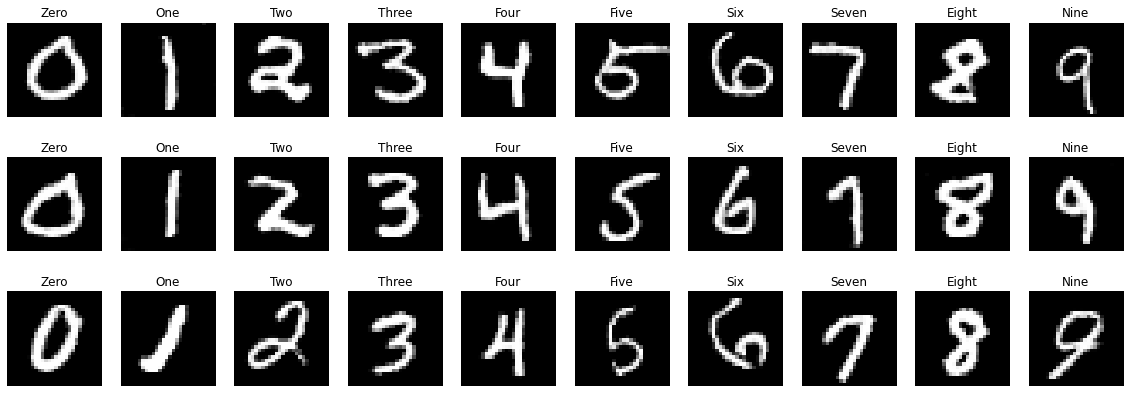

In [28]:
generate_images(trained_generator, num_samples=3)

Each row of images above was generated with a different random latent input vector to show the variations that can occur for each of the 10 digits in the dataset. The examples shown here are pretty much indistinguishable from real images. It is also impressive that the model is able to exhibit a lot of diversity for each of the digits while still maintaining realism for all the images.

### 13 GAN Training Intuition

In this final section of the notebook, we will explore some of the nuances associated with training GANs with the motivation to gain some additional insight into how they work.

During the initial stages of GAN/CGAN training during the first few epochs, it is difficult for the generator to generate plausible images, and therefore, the generator loss is high. At the same time, the Discriminator's job is relatively easy, and therefore, the Discriminator loss is relatively low. This is fairly typical behavior in the early stages of training. However, we can gain further insight beyond this simple observation by considering what happens at the mini-batch level during the first few epochs.

### 13.1 Discriminator Training

The Discriminator is trained with an equal batch of Real and Fake images along with their corresponding ground truth labels. At the beginning of training, the generator produces noise for images, but the Discriminator hasn’t been trained to distinguish the difference between noise and real images. Therefore, the Discriminator produces predictions of roughly 0.5 for both types of images (real/fake) in the first few mini-batches of the first epoch. With each additional mini-batch, the Discriminator starts to quickly learn the difference between real and fake images since the fake images are of poor quality. The plot below shows the discriminator output for a single batch of real and fake images during the first epoch of training (data points at every 10 mini-batches).

<img src="https://opencv.org/wp-content/uploads/2022/09/c4-gan-mini-batch-plot.png" width=1000>

As the two curves diverge it is clear that the discriminator has learned how to tell the difference between real images and poor-quality fake images like the ones shown below.


<img src="https://opencv.org/wp-content/uploads/2022/09/c4-gan-poor-fake-images.png" width=1000>

As training continues and the generator eventually starts to produce more realistic images, the predictions from the discriminator for both real and fake images start to become more similar, indicating that the discriminator is less sure about whether or not the images are real or fake. This is where the two curves start to align with each other but also exhibit a strong oscillatory behavior. Notice that throughout the plot above, the predictions for the real images (blue) are almost exclusively higher than the predictions for the fake images (green). This makes sense since there is still enough difference between generated images and the real images in the first few epochs of training, as shown below.

Fake images after 1 epoch.
<img src="https://opencv.org/wp-content/uploads/2022/09/c4-gan-fake-images-1-epoch.png" width=1000>

Real images.
<img src="https://opencv.org/wp-content/uploads/2022/09/c4-gan-real-images.png" width=1000>

To understand this better, consider the situation where the discriminator starts to score both types of images higher (i.e., both real and fake images are scored as more likely to be real). Let’s now take a look at the discriminator loss at this point when the predictions for real and fake images are both high.

Discriminator Loss:

$$\mathcal{L^{D}} = - \frac{1}{n}\sum_{i=1}^n\  [\ y_i\ log(D(x_i)) +\ (1-y_i)\ log(1-D(G(z_i))) \ ]$$


The Discriminator Loss for **Real** images is:


$$\mathcal{L^{D}} = - \frac{1}{n}\sum_{i=1}^n\  \ y_i\ log(D(x_i)) $$

Since the prediction from the discriminator, $D(x)$, is high, the loss contribution is minimal.

The Discriminator Loss for **Fake** images is:

$$\mathcal{L^{D}} = - \frac{1}{n}\sum_{i=1}^n\  (1-y_i)\ log(1-D(G(z_i))) \ $$

Since $D(G(z))$ is also high, the loss contribution is significant, and therefore, the discriminator weights are updated in a direction to reduce the loss. In the next mini-batch, the updated weights will generally tend to drive the predictions for both image types (real and fake) lower.

### 13.2 Generator Training

At each training step, the generator is also trained, but only on fake images supplied to the discriminator but with “real” labels. The generator loss, therefore, has just a single term.

$$\mathcal{L^{G}} = - \frac{1}{n} \sum_{i=1}^n \ [\  y_i\ log(D(G(z_i))) \ ]$$


We supply real labels because we want the generator loss to be high if the prediction for the fake images is not high. So, if the discriminator predicts a low value for the fake images, the loss computed for the generator will be high. For example:

$$ -log (.1) = 2.3$$
$$ -log (.9) = 0.1$$


### 13.3 Loss Curves

After many epochs of training, the loss curves in this example reach an equilibrium state as shown in the training plot below. 

<img src="https://opencv.org/wp-content/uploads/2022/09/c4-gan-cgan-loss-curves.png" width=1000>

### 13.4 Discriminator Predictions
If we monitor the discriminator predictions for real and fake images during the training process, as shown in the next plot below, we see the oscillatory behavior as described above but at a larger scale. There are two important things to note about this. First, the two curves both tend to stabilize at a value close to 0.5, but the apparent “convergence” is really due to the fact that we adjusted the discriminator learning rate during training which has the effect of reducing the magnitude of the weight updates and therefore dampens the magnitude of the oscillations. **The more important thing to notice is that the distance between the curves is much closer after we reach an equilibrium state compared to earlier in the training process.** So, the “convergence” is better represented as the distance between the two curves and their average value (regardless of the oscillations that may be present).

<img src="https://opencv.org/wp-content/uploads/2022/09/c4-gan-cgan-prediction-plot.png" width=1000>

There are many metrics that have been developed to assess both the image quality and diversity of images generated by GANs. The discussion of these metrics is beyond the scope of this introductory module, but we have provided the following paper as a reference <a href="https://arxiv.org/pdf/2103.09396.pdf" target="_blank">GAN Evaluation Measures</a>.

## 14 Conclusion

CGAN is a GAN variant in which both the Generator and the Discriminator are conditioned on auxiliary data (such as a class label) during training. In CGANs, the input labels can be represented as one-hot encoded slices or by dense (embedded) vectors that are learned by the networks. In both cases, the labels are combined with a transformed representation of the latent vector in the upstream portion of the network of the Generator network. Similar processing also takes place in the Discriminator, where the labels are combined with the input image. In both cases, you can think of these label representations as a means for activating the neurons associated with a particular label to synthesize an image based on a specified input label. We can, therefore, loosely think of the conditional Generator as being composed of N separate unconditional GAN models (one for each label in the dataset). This is just an analogy but a helpful mnemonic for building the intuition for how CGANs work.

In this notebook, we chose to use the MNSIT dataset for simplicity so that we could focus on the fundamental building blocks of a CGAN. Building intuition is important before moving on to more complex models and datasets, and using a simple dataset allowed us to study a simple CGAN model with well-behaved training behavior. Keep in mind that GANs are notoriously hard to train for more complex datasets and models due to the dynamic nature of balancing two loss functions during the training process. However, you should now have a solid foundation for tackling more complex systems. It is also highly recommended to use the best practices that we have covered in this module. Here is another source on <a href="https://github.com/soumith/ganhacks" target="_blank">GAN hacks</a> to add to the list.